# 03 - Chaos Gradient Testing

Test how LLM accuracy degrades as document quality decreases.

**The Question:** At what point does chaos break the model?

**Method:**
1. Take clean documents
2. Apply increasing levels of degradation (noise, blur, rotation)
3. Measure extraction accuracy at each level
4. Find the "chaos threshold" where accuracy collapses

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from PIL import Image

from src.data_loader import DataLoader, Document
from src.extractors import ClaudeExtractor, OllamaExtractor
from src.evaluators import ExtractionEvaluator
from src.utils import create_chaos_gradient, add_noise_to_image, save_results

In [2]:
# Initialize
loader = DataLoader("../data")
evaluator = ExtractionEvaluator()

## Visualize Chaos Levels

First, let's see what different chaos levels look like.

In [3]:
# Load a sample document
sample_docs = list(loader.load_samples())

if not sample_docs:
    # Try FUNSD
    try:
        sample_docs = list(loader.load_funsd())[:1]
    except:
        print("No documents available. Run: python src/download_data.py")

if sample_docs:
    base_doc = sample_docs[0]
    base_img = base_doc.load_image()
    print(f"Using document: {base_doc.id}")

Using document: sample_form


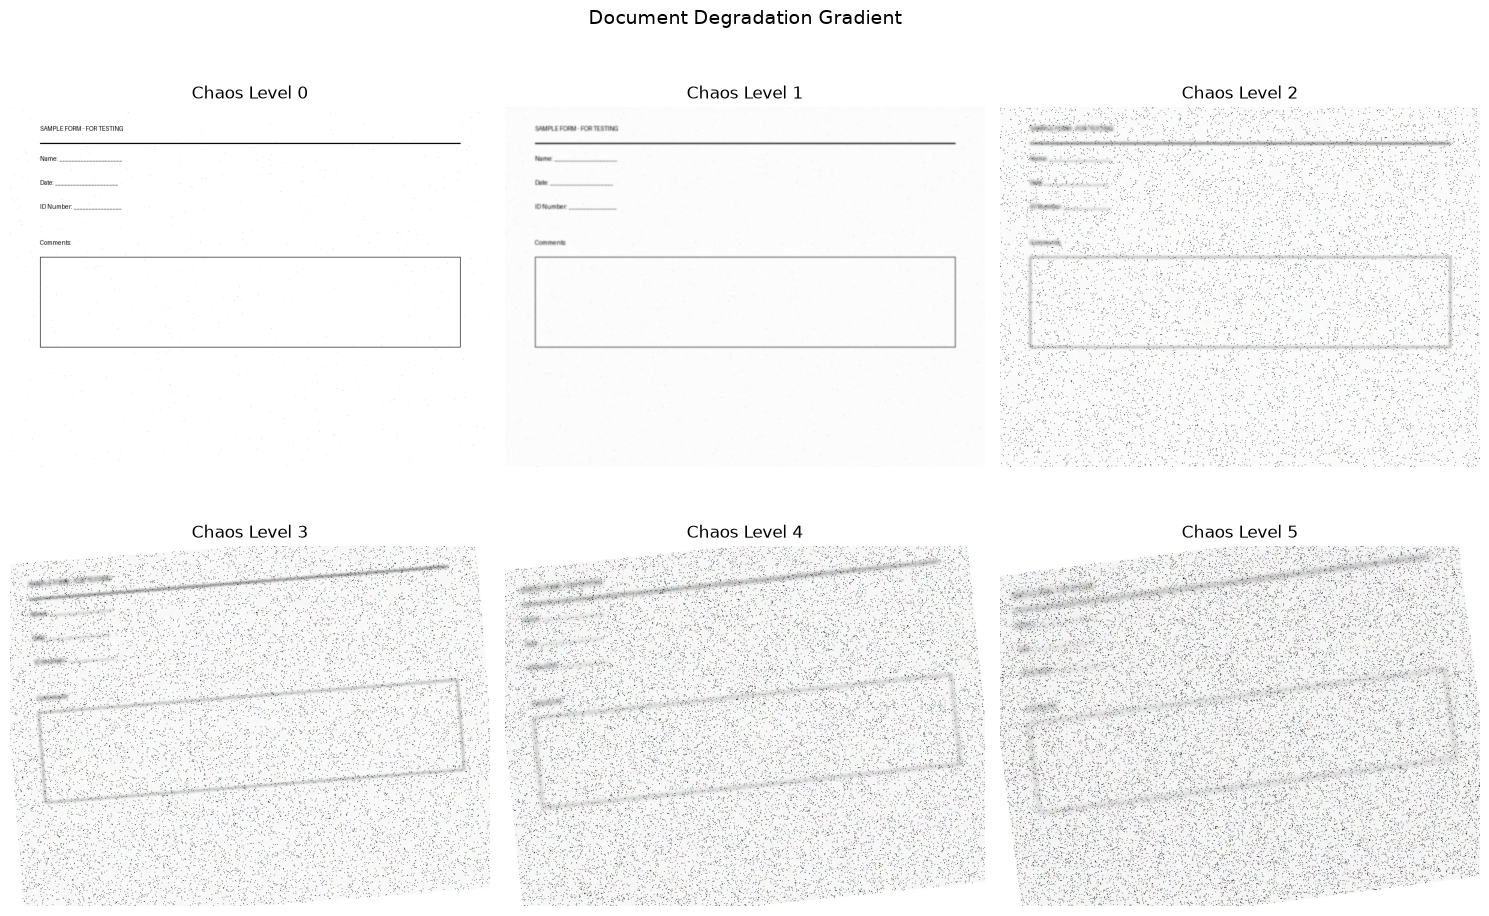

In [4]:
# Create and visualize chaos gradient
if sample_docs:
    chaos_levels = create_chaos_gradient(base_img, num_levels=5)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, (level, img) in enumerate(chaos_levels):
        axes[i].imshow(img)
        axes[i].set_title(f"Chaos Level {level}")
        axes[i].axis('off')
    
    plt.suptitle("Document Degradation Gradient", fontsize=14)
    plt.tight_layout()
    plt.savefig("../results/chaos_gradient_visual.png", dpi=150)
    plt.show()

## Individual Noise Types

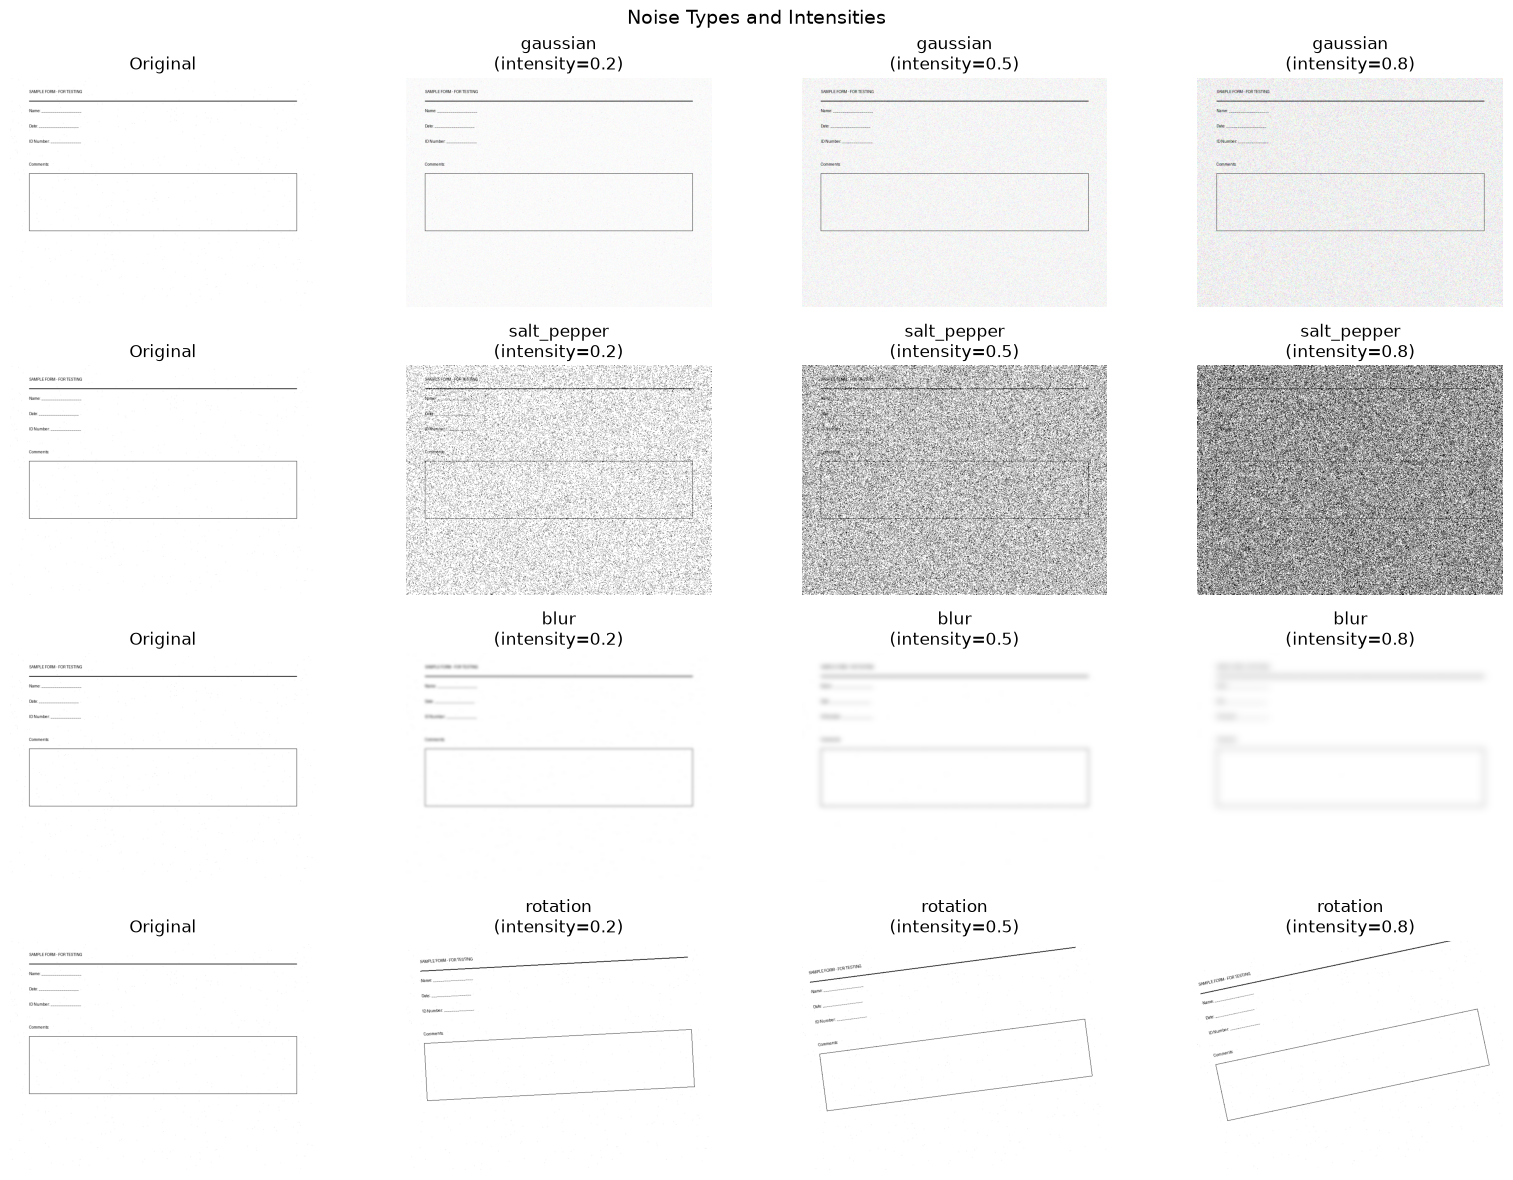

In [5]:
# Visualize individual noise types
if sample_docs:
    noise_types = ["gaussian", "salt_pepper", "blur", "rotation"]
    intensities = [0.2, 0.5, 0.8]
    
    fig, axes = plt.subplots(len(noise_types), len(intensities) + 1, figsize=(16, 12))
    
    for i, noise_type in enumerate(noise_types):
        # Original
        axes[i, 0].imshow(base_img)
        axes[i, 0].set_title("Original")
        axes[i, 0].axis('off')
        
        # Different intensities
        for j, intensity in enumerate(intensities):
            noisy = add_noise_to_image(base_img, noise_type, intensity)
            axes[i, j + 1].imshow(noisy)
            axes[i, j + 1].set_title(f"{noise_type}\n(intensity={intensity})")
            axes[i, j + 1].axis('off')
    
    plt.suptitle("Noise Types and Intensities", fontsize=14)
    plt.tight_layout()
    plt.savefig("../results/noise_types.png", dpi=150)
    plt.show()

## Run Chaos Tolerance Test

Test extraction accuracy across chaos levels.

In [6]:
# Initialize extractor
try:
    extractor = ClaudeExtractor()
    print("Using Claude for chaos testing")
except:
    try:
        extractor = OllamaExtractor(model="llama3.2-vision")
        print("Using Ollama for chaos testing")
    except:
        extractor = None
        print("No extractor available")

Using Claude for chaos testing


In [7]:
# Load test documents with ground truth
test_docs = []

try:
    funsd = list(loader.load_funsd())[:5]  # Small sample for testing
    test_docs.extend(funsd)
    print(f"Using {len(funsd)} FUNSD documents")
except:
    pass

if not test_docs:
    print("No documents with ground truth available.")
    print("Results will show extraction success but not accuracy.")

Using 5 FUNSD documents


In [8]:
# Run chaos gradient test
chaos_results = []
NUM_LEVELS = 6  # 0 = original, 1-5 = increasing chaos

if extractor and test_docs:
    for doc in tqdm(test_docs, desc="Documents"):
        base_img = doc.load_image()
        gradient = create_chaos_gradient(base_img, num_levels=NUM_LEVELS - 1)
        
        for level, chaos_img in tqdm(gradient, desc=f"Chaos levels for {doc.id}", leave=False):
            # Create temporary document with degraded image
            temp_doc = Document(
                id=f"{doc.id}_chaos{level}",
                image_path=doc.image_path,
                image=chaos_img,
                ground_truth=doc.ground_truth,
                dataset=doc.dataset
            )
            
            # Extract
            result = extractor.extract(temp_doc)
            
            # Evaluate
            if doc.ground_truth:
                eval_result = evaluator.evaluate(
                    result.parsed_data,
                    doc.ground_truth,
                    temp_doc.id,
                    extractor.model_name
                )
                accuracy = eval_result.field_accuracy
                hallucinations = eval_result.hallucinations_detected
            else:
                accuracy = None
                hallucinations = None
            
            chaos_results.append({
                "document_id": doc.id,
                "chaos_level": level,
                "success": result.success,
                "accuracy": accuracy,
                "hallucinations": hallucinations,
                "latency_ms": result.latency_ms,
                "json_valid": result.parsed_data is not None,
            })

    print(f"\nCompleted {len(chaos_results)} extractions")
else:
    print("Cannot run test - missing extractor or documents")

Documents:   0%|          | 0/5 [00:00<?, ?it/s]

Chaos levels for 82092117:   0%|          | 0/6 [00:00<?, ?it/s]

Chaos levels for 82200067_0069:   0%|          | 0/6 [00:00<?, ?it/s]

Chaos levels for 82250337_0338:   0%|          | 0/6 [00:00<?, ?it/s]

Chaos levels for 82251504:   0%|          | 0/6 [00:00<?, ?it/s]

Chaos levels for 82252956_2958:   0%|          | 0/6 [00:00<?, ?it/s]


Completed 30 extractions


## Analyze Chaos Tolerance

In [9]:
# Convert to DataFrame
if chaos_results:
    df = pd.DataFrame(chaos_results)
    display(df.head(10))

,document_id,chaos_level,success,accuracy,hallucinations,latency_ms,json_valid
0,82092117,0,True,0.022222,8,14003.915548,True
1,82092117,1,True,0.022222,7,12971.143484,True
2,82092117,2,True,0.000000,8,10960.628986,True
3,82092117,3,True,0.000000,11,11719.005585,True
4,82092117,4,True,0.000000,2,7399.283409,True
5,82092117,5,True,0.000000,2,8026.182175,True
6,82200067_0069,0,True,0.024793,20,16107.167959,True
7,82200067_0069,1,True,0.016529,21,16485.270262,True
8,82200067_0069,2,True,0.008264,4,8292.771339,True
9,82200067_0069,3,True,0.000000,4,8177.250862,True


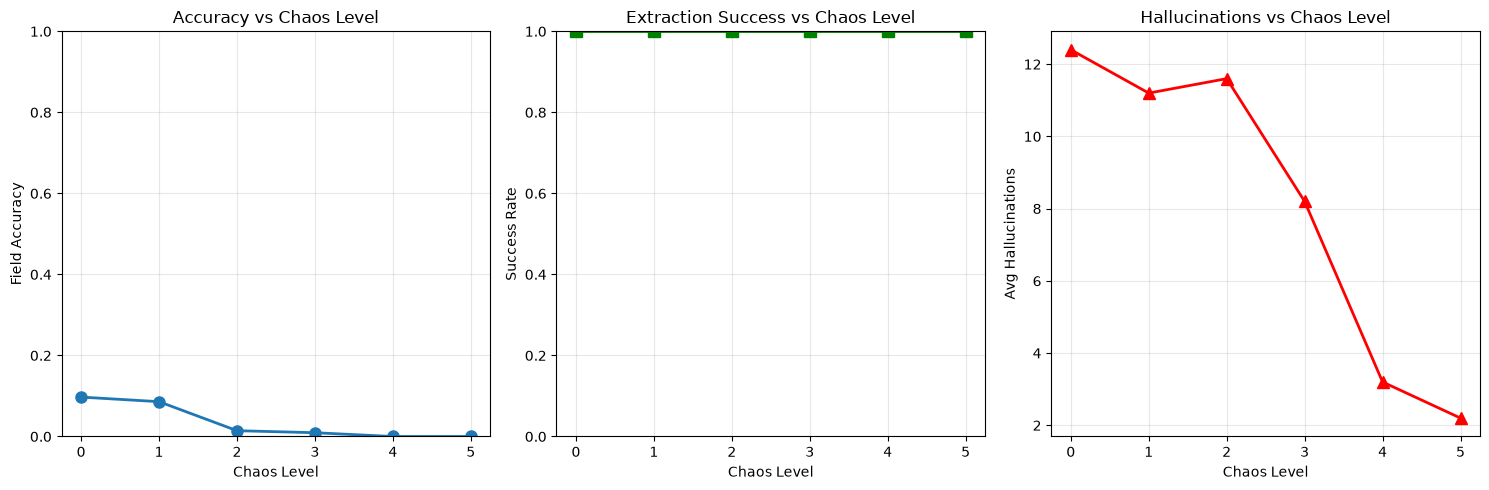

In [10]:
# Accuracy by chaos level
if chaos_results and df["accuracy"].notna().any():
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Accuracy curve
    accuracy_by_level = df.groupby("chaos_level")["accuracy"].mean()
    accuracy_by_level.plot(ax=axes[0], marker='o', linewidth=2, markersize=8)
    axes[0].set_xlabel("Chaos Level")
    axes[0].set_ylabel("Field Accuracy")
    axes[0].set_title("Accuracy vs Chaos Level")
    axes[0].set_ylim(0, 1)
    axes[0].grid(True, alpha=0.3)
    
    # Success rate
    success_by_level = df.groupby("chaos_level")["success"].mean()
    success_by_level.plot(ax=axes[1], marker='s', linewidth=2, markersize=8, color='green')
    axes[1].set_xlabel("Chaos Level")
    axes[1].set_ylabel("Success Rate")
    axes[1].set_title("Extraction Success vs Chaos Level")
    axes[1].set_ylim(0, 1)
    axes[1].grid(True, alpha=0.3)
    
    # Hallucinations
    if df["hallucinations"].notna().any():
        halluc_by_level = df.groupby("chaos_level")["hallucinations"].mean()
        halluc_by_level.plot(ax=axes[2], marker='^', linewidth=2, markersize=8, color='red')
        axes[2].set_xlabel("Chaos Level")
        axes[2].set_ylabel("Avg Hallucinations")
        axes[2].set_title("Hallucinations vs Chaos Level")
        axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("../results/chaos_tolerance_curves.png", dpi=150)
    plt.show()

In [11]:
# Find the "chaos threshold" - where accuracy drops below 50%
if chaos_results and df["accuracy"].notna().any():
    accuracy_by_level = df.groupby("chaos_level")["accuracy"].mean()
    
    threshold_level = None
    for level, acc in accuracy_by_level.items():
        if acc < 0.5:
            threshold_level = level
            break
    
    print("=" * 50)
    print("CHAOS TOLERANCE ANALYSIS")
    print("=" * 50)
    print(f"\nAccuracy by chaos level:")
    for level, acc in accuracy_by_level.items():
        bar = "█" * int(acc * 20)
        print(f"  Level {level}: {bar} {acc:.1%}")
    
    if threshold_level:
        print(f"\n⚠️  CHAOS THRESHOLD: Level {threshold_level}")
        print(f"   Accuracy drops below 50% at chaos level {threshold_level}")
    else:
        print(f"\n✓ Model maintains >50% accuracy across all chaos levels")

CHAOS TOLERANCE ANALYSIS

Accuracy by chaos level:
  Level 0: █ 9.7%
  Level 1: █ 8.6%
  Level 2:  1.4%
  Level 3:  0.9%
  Level 4:  0.0%
  Level 5:  0.0%

✓ Model maintains >50% accuracy across all chaos levels


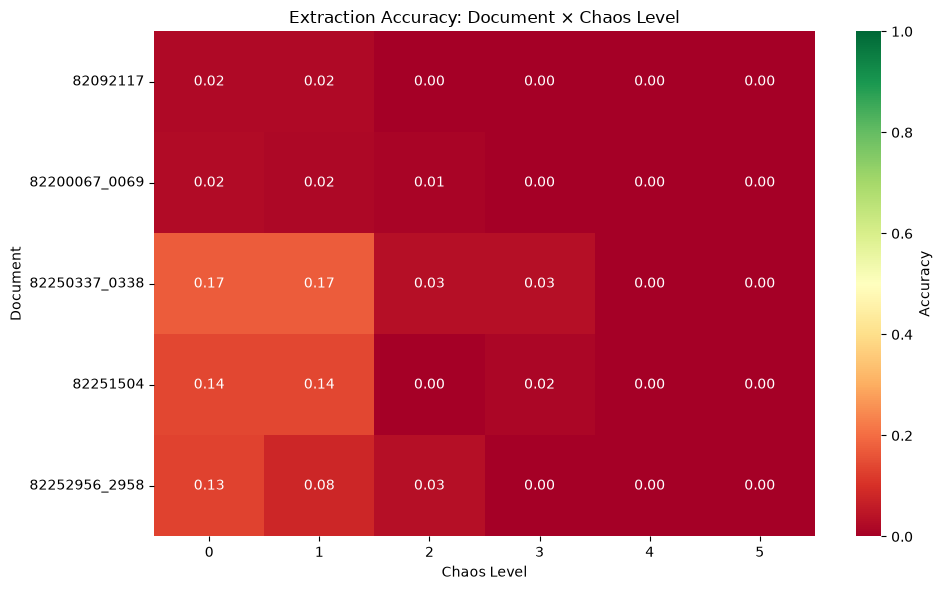

In [12]:
# Heatmap: Document x Chaos Level
if chaos_results and df["accuracy"].notna().any():
    pivot = df.pivot_table(
        values="accuracy",
        index="document_id",
        columns="chaos_level"
    )
    
    plt.figure(figsize=(10, max(6, len(pivot) * 0.4)))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Accuracy"}
    )
    plt.title("Extraction Accuracy: Document × Chaos Level")
    plt.xlabel("Chaos Level")
    plt.ylabel("Document")
    plt.tight_layout()
    plt.savefig("../results/chaos_heatmap.png", dpi=150)
    plt.show()

## Save Results

In [13]:
if chaos_results:
    save_results(chaos_results, "../results/chaos_gradient_results.json")
    df.to_csv("../results/chaos_gradient_summary.csv", index=False)
    print("Results saved to results/")

Results saved to results/


## Key Findings

*Fill in after running experiments*

1. **Chaos Threshold:** Level X is where accuracy drops below 50%
2. **Graceful Degradation:** Does accuracy decline smoothly or collapse suddenly?
3. **Hallucination Trend:** Do hallucinations increase with chaos?